## Import the necessary libraries and the GDSC dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Import dataset
df = pd.read_excel("GDSC.xlsx")
df.head()

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
1,687448,COLO-829,SKCM,1003,Camptothecin,-1.235034,0.867348,0.557727,skin,melanoma,SKCM,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
2,687455,RT4,BLCA,1003,Camptothecin,-2.963191,0.821438,-0.383200,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
3,687457,SW780,BLCA,1003,Camptothecin,-1.449138,0.905050,0.441154,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
4,687459,TCCSUP,BLCA,1003,Camptothecin,-2.350633,0.843430,-0.049682,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication


In [23]:
# Inspect
print(df.shape)
print(df.info())
print(df["DRUG_NAME"].nunique())

(162103, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162103 entries, 0 to 162102
Data columns (total 20 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   COSMIC_ID                                162103 non-null  int64  
 1   CELL_LINE_NAME                           162103 non-null  object 
 2   TCGA_DESC                                162103 non-null  object 
 3   DRUG_ID                                  162103 non-null  int64  
 4   DRUG_NAME                                162103 non-null  object 
 5   LN_IC50                                  162103 non-null  float64
 6   AUC                                      162103 non-null  float64
 7   Z_SCORE                                  162103 non-null  float64
 8   GDSC Tissue descriptor 1                 162103 non-null  object 
 9   GDSC Tissue descriptor 2                 162103 non-null  object 
 10  Cancer Type (matchi

In [6]:
df["IC50_uM"] = np.exp(df["LN_IC50"])

In [25]:
print(df["CELL_LINE_NAME"].nunique())

737


In [26]:
print(df["TCGA_DESC"].nunique())

30


## 1. Dataset Overview

The GDSC dataset contains 162,103 drug-cell line sensitivity measurements across 246 drugs, 737 cancer cell lines, and 30 TCGA cancer types. Each row represents a single drug tested on a single cell line, with the following key variables:

In [8]:
# Convert binary flags to boolean
for col in ["CNA", "Gene Expression", "Methylation"]:
    df[col] = df[col].map({"Y": True, "N": False})

## 2. Data Quality & Cleaning


In [33]:
# Check for Missing values
missing_count = df.isna().sum()
print("Missing Values: ", missing_count)

Missing Values:  COSMIC_ID                                  0
CELL_LINE_NAME                             0
TCGA_DESC                                  0
DRUG_ID                                    0
DRUG_NAME                                  0
LN_IC50                                    0
AUC                                        0
Z_SCORE                                    0
GDSC Tissue descriptor 1                   0
GDSC Tissue descriptor 2                   0
Cancer Type (matching TCGA label)          0
Microsatellite instability Status (MSI)    0
Screen Medium                              0
Growth Properties                          0
CNA                                        0
Gene Expression                            0
Methylation                                0
TARGET                                     0
TARGET_PATHWAY                             0
IC50_uM                                    0
dtype: int64


In [34]:
# Check for Duplicate Rows
duplicate_count = df.duplicated().sum()
print("Duplicate Count: ", duplicate_count)

Duplicate Count:  0


In [32]:
df["AUC"].value_co()

AUC
0.995708    20
0.979174    19
0.993806    18
0.986537    15
0.980923    14
            ..
0.690074     1
0.702911     1
0.690007     1
0.808667     1
0.691158     1
Name: count, Length: 109624, dtype: int64

In [35]:
# AUC Validity
auc_min, auc_max = df["AUC"].min(), df["AUC"].max()
print("AUC range:", auc_min, "to", auc_max)

AUC range: 0.006282 to 0.998904


In [36]:
# 4. LN_IC50 range and median
ln_ic50_min, ln_ic50_max = df["LN_IC50"].min(), df["LN_IC50"].max()
ln_ic50_median = df["LN_IC50"].median()
print("LN_IC50 range:", ln_ic50_min, "to", ln_ic50_max)
print("LN_IC50 median:", ln_ic50_median)

LN_IC50 range: -8.642551 to 13.820189
LN_IC50 median: 3.271447


In [37]:
# Percent of values outside 1st–99th percentile
lower_q = df["LN_IC50"].quantile(0.01)
upper_q = df["LN_IC50"].quantile(0.99)
outside = ((df["LN_IC50"] < lower_q) | (df["LN_IC50"] > upper_q)).mean() * 100
print(f"{outside:.2f}% of values fall outside the 1st–99th percentile range")

2.00% of values fall outside the 1st–99th percentile range


In [38]:
# Back-transform IC50 from LN_IC50
df["IC50_uM"] = np.exp(df["LN_IC50"])

Missing values: None detected across all 162,103 rows and 19 columns

Duplicate rows: None (exact duplicates or drug–cell line pair duplicates)

AUC validity: All values fall within [0, 1] as expected

LN_IC50 range: −8.64 to +13.82 (median = 3.27); 2% of values fall outside the 1st–99th percentile range

Preprocessing steps: Columns renamed for clarity; IC50_uM back-transformed from LN_IC50; binary flags converted to boolean

## 3. Drug Sensitivity Patterns


## 2. Global Distributions

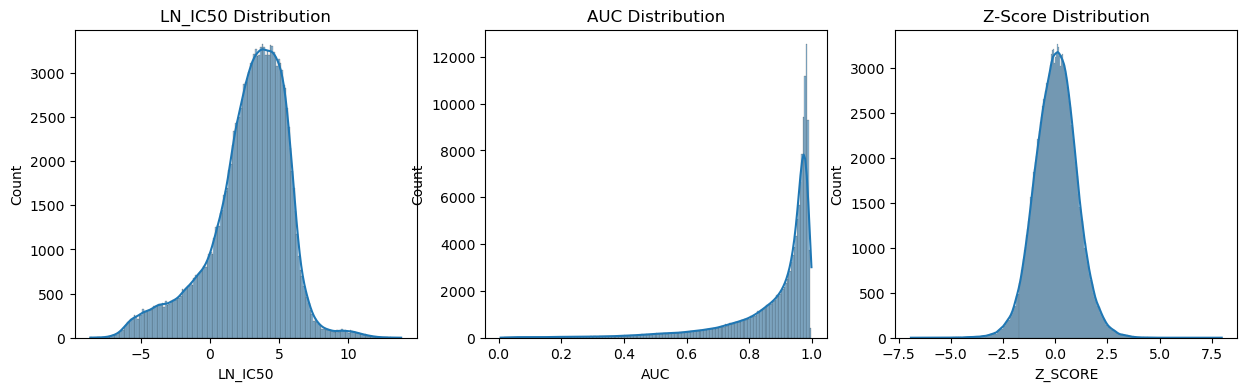

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df["LN_IC50"], kde=True, ax=axes[0])
axes[0].set_title("LN_IC50 Distribution")

sns.histplot(df["AUC"], kde=True, ax=axes[1])
axes[1].set_title("AUC Distribution")

sns.histplot(df["Z_SCORE"], kde=True, ax=axes[2])
axes[2].set_title("Z-Score Distribution")

plt.show()


## 3. Drug Sensitivity Patterns

### Most & Least Effective Drugs

Top 15 most potent drugs:
 DRUG_NAME
Romidepsin             -5.317812
Bortezomib             -4.906318
Sepantronium bromide   -4.210507
Docetaxel              -3.990660
Daporinad              -3.902214
Dactinomycin           -3.820755
Vinblastine            -3.783500
SN-38                  -3.510652
Paclitaxel             -3.194081
Eg5_9814               -3.137055
Vinorelbine            -3.117927
Dinaciclib             -2.983147
Staurosporine          -2.667322
Luminespib             -2.402346
Camptothecin           -2.391764
Name: LN_IC50, dtype: float64
Top 15 least potent drugs:
 DRUG_NAME
AZD1208                   5.377112
GSK3337463A               5.377516
Lenalidomide              5.379646
MIRA-1                    5.404574
PFI3                      5.464875
LMB_AB1                   5.490826
GSK2830371                5.587867
Dacarbazine               5.589772
EPZ5676                   5.622295
Motesanib                 5.640039
Temozolomide              6.507988
alpha-lipoic ac

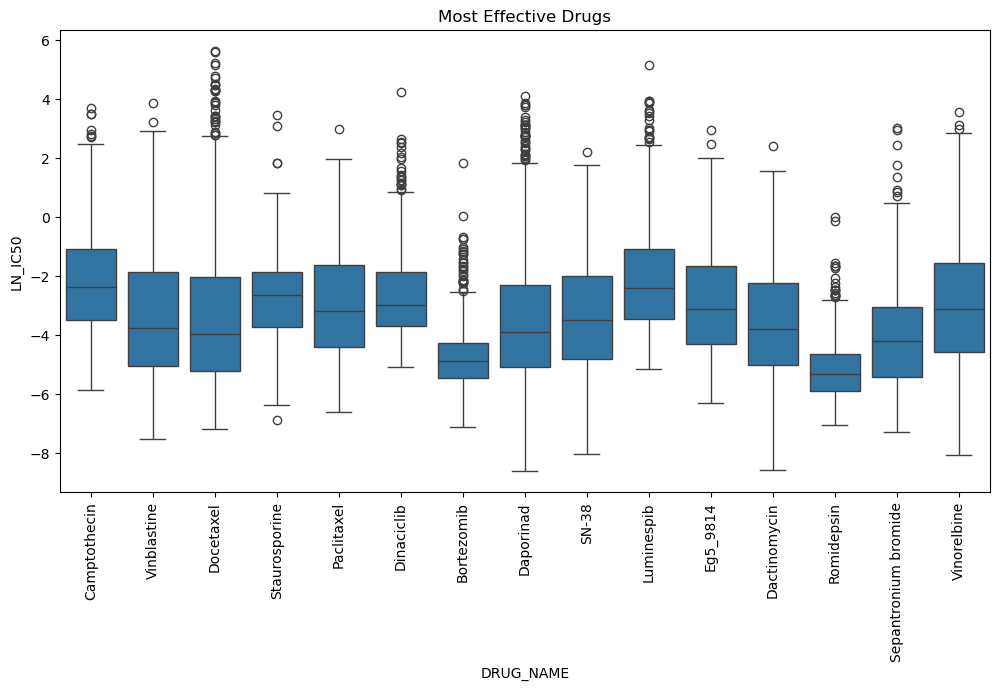

In [10]:
drug_medians = df.groupby("DRUG_NAME")["LN_IC50"].median().sort_values()

print("Top 15 most potent drugs:\n", drug_medians.head(15))
print("Top 15 least potent drugs:\n", drug_medians.tail(15))

# Boxplot for most effective drugs
top_drugs = drug_medians.head(15).index
plt.figure(figsize=(12,6))
sns.boxplot(x="DRUG_NAME", y="LN_IC50", data=df[df["DRUG_NAME"].isin(top_drugs)])
plt.xticks(rotation=90)
plt.title("Most Effective Drugs")
plt.show()


### Most Variable Drugs

Top 10 most variable drugs:
 DRUG_NAME
Gemcitabine     2.941950
AZD5991         2.759418
Daporinad       2.735583
Docetaxel       2.546911
BI-2536         2.459347
Dasatinib       2.394058
Methotrexate    2.389344
Tozasertib      2.386865
AZD5582         2.345364
Trametinib      2.301612
Name: LN_IC50, dtype: float64


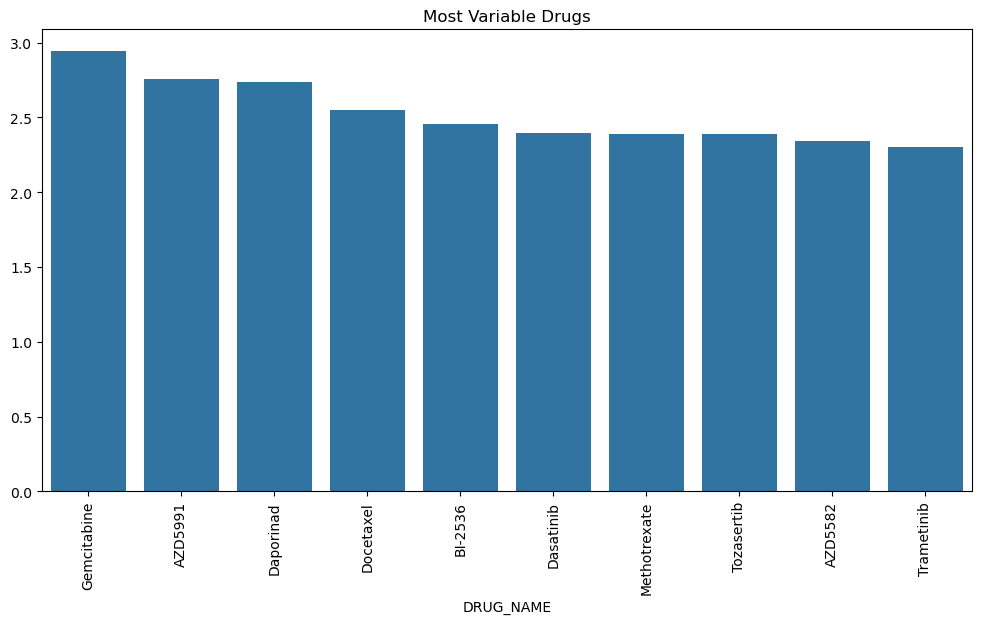

In [11]:
drug_std = df.groupby("DRUG_NAME")["LN_IC50"].std().sort_values(ascending=False)
print("Top 10 most variable drugs:\n", drug_std.head(10))

plt.figure(figsize=(12,6))
sns.barplot(x=drug_std.head(10).index, y=drug_std.head(10).values)
plt.xticks(rotation=90)
plt.title("Most Variable Drugs")
plt.show()


### 4. Cancer Cell Line Analysis

Most sensitive cancer types:
 TCGA_DESC
CLL     1.553044
LAML    2.043654
ALL     2.063221
DLBC    2.096066
LCML    2.162442
MM      2.470976
ACC     2.819815
NB      2.851345
MB      2.939177
HNSC    3.119146
Name: LN_IC50, dtype: float64
Most resistant cancer types:
 TCGA_DESC
LUSC    3.593490
OV      3.594032
LGG     3.643098
THCA    3.668516
PRAD    3.681222
LUAD    3.732755
LIHC    3.828824
UCEC    3.843761
MESO    3.860915
PAAD    4.165059
Name: LN_IC50, dtype: float64


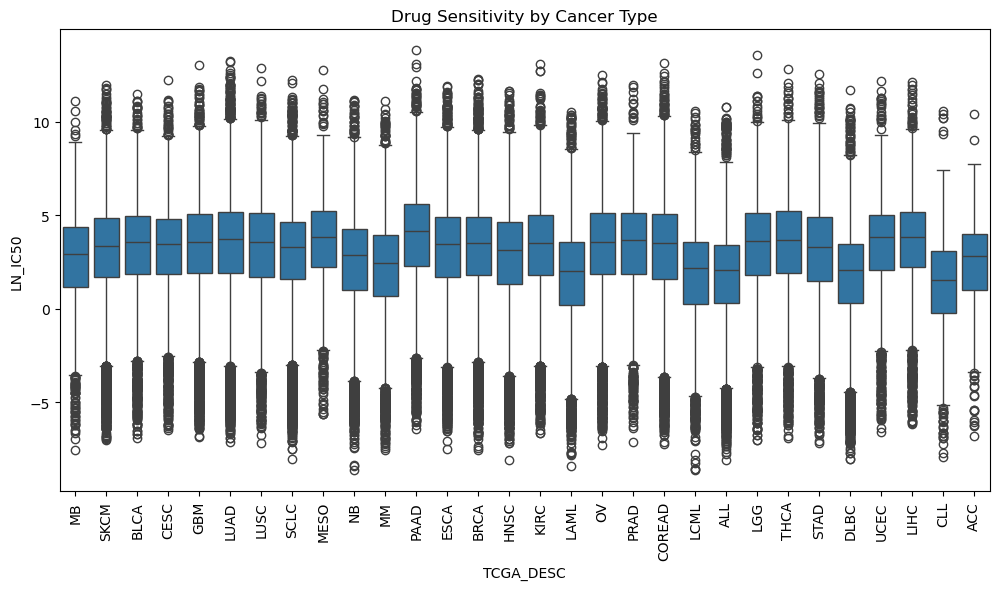

In [12]:
# Median LN_IC50 per cancer type
cancer_medians = df.groupby("TCGA_DESC")["LN_IC50"].median().sort_values()
print("Most sensitive cancer types:\n", cancer_medians.head(10))
print("Most resistant cancer types:\n", cancer_medians.tail(10))

plt.figure(figsize=(12,6))
sns.boxplot(x="TCGA_DESC", y="LN_IC50", data=df)
plt.xticks(rotation=90)
plt.title("Drug Sensitivity by Cancer Type")
plt.show()


The most drug-resistant cancer types are PAAD (pancreatic, median LN_IC50 = 4.17), UCEC (endometrial), and LIHC (liver) — consistent with the known clinical challenge of treating these cancers.

### 5. Genomic & Molecular Influences

#### LN_IC50 vs AUC Correlation

Pearson correlation: 0.7604472117287249
Spearman correlation: 0.7692449155586694


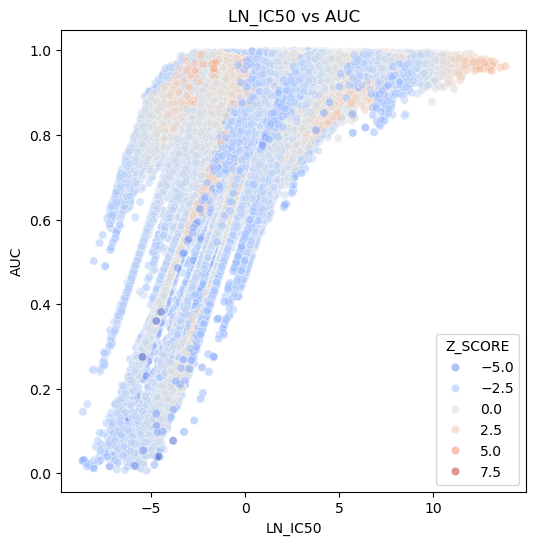

In [13]:
from scipy.stats import pearsonr, spearmanr

pearson_r, _ = pearsonr(df["LN_IC50"], df["AUC"])
spearman_r, _ = spearmanr(df["LN_IC50"], df["AUC"])
print("Pearson correlation:", pearson_r)
print("Spearman correlation:", spearman_r)

plt.figure(figsize=(6,6))
sns.scatterplot(x="LN_IC50", y="AUC", data=df, hue="Z_SCORE", palette="coolwarm", alpha=0.5)
plt.title("LN_IC50 vs AUC")
plt.show()


#### MSI Status

In [16]:
msi_groups = df.groupby("Microsatellite instability Status (MSI)")["LN_IC50"].median()
print("Median LN_IC50 by MSI status:\n", msi_groups)

from scipy.stats import mannwhitneyu
msi_h = df[df["Microsatellite instability Status (MSI)"]=="MSI-H"]["LN_IC50"]
mss = df[df["Microsatellite instability Status (MSI)"]!="MSI-H"]["LN_IC50"]
stat, p = mannwhitneyu(msi_h, mss)
print("Mann-Whitney U p-value:", p)


Median LN_IC50 by MSI status:
 Microsatellite instability Status (MSI)
MSI-H        2.996535
MSS/MSI-L    3.293239
Name: LN_IC50, dtype: float64
Mann-Whitney U p-value: 3.8078404168508164e-32


## Growth Properties

Median LN_IC50 by growth properties:
 Growth Properties
Adherent         3.520082
Semi-Adherent    3.335541
Suspension       2.441651
Name: LN_IC50, dtype: float64


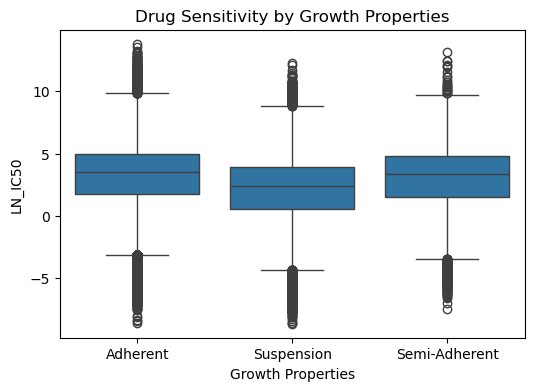

In [19]:
growth_medians = df.groupby("Growth Properties")["LN_IC50"].median()
print("Median LN_IC50 by growth properties:\n", growth_medians)

plt.figure(figsize=(6,4))
sns.boxplot(x="Growth Properties", y="LN_IC50", data=df)
plt.title("Drug Sensitivity by Growth Properties")
plt.show()


### Genomic Data Availability

In [20]:
for col in ["CNA", "Gene Expression", "Methylation"]:
    print(col, df.groupby(col)["LN_IC50"].median())


CNA CNA
False    3.508225
True     3.269899
Name: LN_IC50, dtype: float64
Gene Expression Gene Expression
False    2.830496
True     3.283111
Name: LN_IC50, dtype: float64
Methylation Methylation
False    3.211147
True     3.272621
Name: LN_IC50, dtype: float64
